In [1]:
import pandas as pd
import copy
import numpy as np

In this notebook I want to explore how adding the inverse of temperature and wind speed cubed effects the Random Forest. Adding Wind speed cubed improved kNN significantly. In the last section titled "Cross-Validating Random Forest and XGBoost for comparison with other models" I test these models on the cross-validation scheme of training on 2019-2021 and then testing on 2022.

In [5]:
ogdf = pd.read_csv('../../1_data/final_dataframes/main_validation_dataframe.csv')
houroutdf=copy.deepcopy(ogdf)
houroutdf = houroutdf.rename(columns={'Wind': 'Wind_Power'}) #renaming target variable

In [6]:
#removing categorical stuff
houroutdf_no_categorical = copy.deepcopy(houroutdf)
houroutdf_no_categorical = houroutdf_no_categorical.drop(columns=['MonthDay', 'time'])
houroutdf_no_categorical = houroutdf_no_categorical.drop(columns=['Unnamed: 0', 'Year']) #removing some other variables I don't want/need right now

In [7]:
#changing wind direction to (x,y) coordinates, removing times, unnamed column, year
houroutdf_numerical = copy.deepcopy(houroutdf_no_categorical)
for i in range(1, 40):
    col = f"wind_direction_10m_{i}"
    radians = np.deg2rad(houroutdf_no_categorical[col])
    houroutdf_numerical[f"wind_direction_10m_x_{i}"] = np.cos(radians)
    houroutdf_numerical[f"wind_direction_10m_y_{i}"] = np.sin(radians)

houroutdf_numerical  = houroutdf_numerical [[c for c in houroutdf_numerical .columns if c != 'Wind_Power'] + ['Wind_Power']]

In [8]:
# since theoretically the wind power depends on speed cubed, so we modify the columns as well
def make_speed_cubed_df(df):
    new_cols = []

    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        cube_col = df[spd_col] ** 3
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubed': cube_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_speed_cubed = df_new.copy()  # defragment
    return df_speed_cubed
houroutdf_numerical_cubed = make_speed_cubed_df(houroutdf_numerical)

In [9]:
# since theoretically the wind power depends on the inverse of temperature we modify temperature
def make_inverse_temp_df(df):
    new_cols = []

    for i in range(1, 40):
        temp_col = f'temperature_2m_{i}'
        inv_col = 1/ (df[temp_col] + 273.15)
        
        new_cols.append(pd.DataFrame({
            f'{temp_col}_inverse_kelvins': inv_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'temperature_2m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_speed_cubed = df_new.copy()  # defragment
    return df_speed_cubed
houroutdf_numerical_cubed_inverse = make_inverse_temp_df(houroutdf_numerical_cubed)

In [10]:
houroutdf_numerical_cubed_inverse  = houroutdf_numerical_cubed_inverse [[c for c in houroutdf_numerical_cubed_inverse.columns if c != 'Wind_Power'] + ['Wind_Power']]

## Doing PCA on this new data

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [12]:
#scale the features and do PCA on them
# Function from earlier
features = houroutdf_numerical_cubed_inverse.drop(columns=['Wind_Power'])
target = houroutdf_numerical_cubed_inverse.iloc[:, -1]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

houroutdf_numerical_cubed_inverse_scaled = pd.DataFrame(features_scaled, columns=features.columns)
houroutdf_numerical_cubed_inverse_scaled['Wind_Power'] = target.values


In [13]:
#implementing PCA on features
n= 10 #this is the number of features
pca =  PCA(n_components = n)
features_pca = pca.fit_transform(features_scaled)
pca_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
houroutdf_pca = pd.DataFrame(features_pca, columns=pca_columns, index=houroutdf_numerical_cubed_inverse.index)
houroutdf_pca['Wind_Power'] = target.values

## Implementing Models

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt

In [15]:
df = houroutdf_pca

X = df.drop(columns=['Wind_Power'])
y = df['Wind_Power']

In [16]:
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # Avoid division by zero
    denominator = np.where(denominator == 0, 1e-8, denominator)
    smape_value = np.mean(np.abs(y_pred - y_true) / denominator) * 100
    return smape_value

MAPE: 142188683857044.1562
MAE: 142188683857044.1562
R² Score: 0.7577
SMAPE: 32.89%


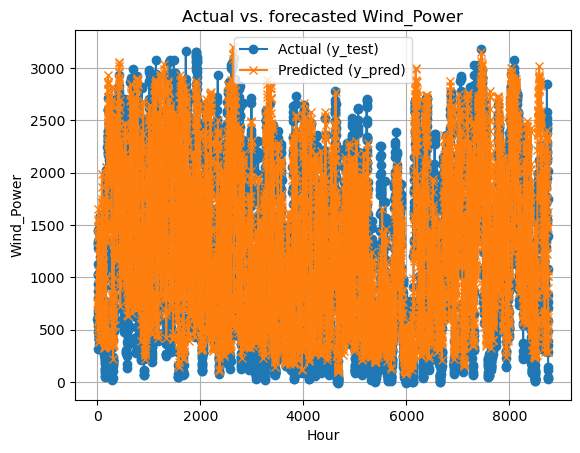

In [69]:
# training Parameters
train_start = 0 #in days, starting at midnight in Quebec
train_days =  1096
train_hours = train_days * 24
test_days = 365
train_end = train_start + train_hours

test_hours = test_days * 24

#model hyperparameters
estimators = 150
depth = 20
randomstate= 614

#some things to initialize
#mape_scores = []
#r2_scores = []
y_pred = np.array([])

X_train = X.iloc[train_start:train_end]
y_train = y.iloc[train_start:train_end]

X_test = X.iloc[train_end:train_end+test_hours]
y_test = y.iloc[train_end:train_end+test_hours]

model = RandomForestRegressor(n_estimators=estimators, max_depth=depth, random_state=randomstate)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mape:.4f}")
print(f"R² Score: {r2:.4f}")
result = smape(y_test, y_pred)
print(f"SMAPE: {result:.2f}%")

#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Hour')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
mae = mean_absolute_error(y_test, y_pred)
mae
mae / houroutdf_pca["Wind_Power"].mean()

np.float64(0.23012281240452495)

It seems that the RF isn't predicting near zero values, which is making the MAPE not a useful metric.

## Trying XGBoost

In [17]:
import xgboost as xgb

MAPE: 99800495905402.7188
MAE: 312.3533
R² Score: 0.7330
filtered MAPE: 69.1666
SMAPE: 33.64%


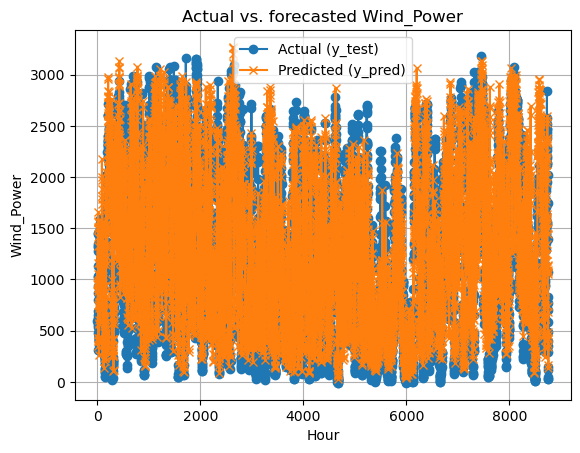

In [137]:
# training Parameters
train_start = 0 #in days, starting at midnight in Quebec
train_days =  1096
train_hours = train_days * 24
test_days = 365
train_end = train_start + train_hours

test_hours = test_days * 24

# Set XGBoost parameters for regression using decision trees
params = {
    "objective": "reg:squarederror",   # regression with squared loss
    "max_depth": 20,                    # depth of each tree
    "eta": 0.1,                        # learning rate
    "nthread": 4,                      # number of threads
    "eval_metric": "rmse"             # evaluation metric
}

# Train the model
num_rounds = 100

#some things to initialize
#mape_scores = []
#r2_scores = []
y_pred = np.array([])

X_train = X.iloc[train_start:train_end]
y_train = y.iloc[train_start:train_end]

X_test = X.iloc[train_end:train_end+test_hours]
y_test = y.iloc[train_end:train_end+test_hours] 

dtrain = xgb.DMatrix(X_train, label=y_train) #convert data type for XGB
dtest = xgb.DMatrix(X_test, label=y_test)

model = xgb.train(params, dtrain, num_rounds)

y_pred = model.predict(dtest)

mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

epsilon = 1e-6
mask = np.abs(y_test) > epsilon
filtered_mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100




print(f"MAPE: {mape:.4f}")

print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"filtered MAPE: {filtered_mape:.4f}")
result = smape(y_test, y_pred)
print(f"SMAPE: {result:.2f}%")

#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Hour')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()

## Another Strategy
In this section we will try Random Forest and XGBoost on this new data, after we combine each days weather data together, and then predict the next days total power generation.

In [18]:
df = houroutdf_numerical_cubed_inverse_scaled.drop("Wind_Power", axis=1)

In [19]:
#combine the rows

n = 24  # number of rows per interval
num_rows, num_cols = df.shape

# Ensure number of rows is divisible by 24
assert num_rows % n == 0, "Number of rows must be divisible by 24"

# Reshape
reshaped = (
    df.to_numpy()
    .reshape(-1, n, num_cols)        # shape: (num_rows // 24, 24, num_cols)
    .transpose(0, 2, 1)              # shape: (num_rows // 24, num_cols, 24)
    .reshape(-1, num_cols * n)       # final shape: (num_rows // 24, num_cols * 24)
)

# Create new column names
new_columns = [
    f'{col}_{i}' for i in range(n) for col in df.columns
]

# Final DataFrame
reshaped_df = pd.DataFrame(reshaped, columns=new_columns)

print(reshaped_df.shape)
onedayforecastdf = copy.deepcopy(reshaped_df)

(1461, 5616)


In [20]:
#now we need to take the entries in 'Wind_power' and then add n=24 of them together for power one day ahead
n=24
dayoutdf = copy.deepcopy(houroutdf)
dayoutdf['Wind_Power'] = dayoutdf['Wind_Power'].rolling(window=n).sum().shift(-n) #this replaces 'Wind' time t with the sum of the entries in 'Wind' at t+1,... t+24
dayoutdf = dayoutdf.iloc[:-24] #removing last 24 entries

In [21]:
df2 = dayoutdf[::24]
df2 = df2.reset_index(drop=True)
onedayforecastdf['Day_Ahead_Power'] = df2['Wind_Power']
onedayforecastdf = onedayforecastdf.iloc[:-1]

In [22]:
#scale the features and do PCA on them
# Function from earlier
features = onedayforecastdf.drop(columns=['Day_Ahead_Power'])
target = onedayforecastdf.iloc[:, -1]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

onedayforecastdf_scaled = pd.DataFrame(features_scaled, columns=features.columns)
onedayforecastdf_scaled['Day_Ahead_Power'] = target.values


In [23]:
#implementing PCA on features
n= 10 #this is the number of featur
pca =  PCA(n_components = n)
features_pca = pca.fit_transform(features_scaled)
pca_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
onedayforecastdf_pca = pd.DataFrame(features_pca, columns=pca_columns, index=onedayforecastdf.index)
onedayforecastdf_pca['Day_Ahead_Power'] = target.values
onedayforecastdf_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Day_Ahead_Power
0,17.380784,31.252792,40.279786,17.719654,9.443087,-29.441790,-7.961485,13.317014,10.984417,9.958747,53069.0
1,67.732971,18.221471,-15.391598,-7.063577,-20.232874,6.975405,10.389889,-11.083831,4.404163,3.629037,37515.0
2,11.744824,45.346017,2.743406,-27.197720,-26.651433,-22.978930,10.723373,0.230056,-6.301367,5.946579,17827.0
3,-0.085424,22.541132,29.650685,-17.825393,-28.088183,-5.691253,0.232787,-1.722544,-0.533869,2.184943,31884.0
4,-13.170692,27.072197,7.425007,4.596676,-32.087177,5.503717,3.062651,12.258509,-1.361053,-15.678742,3776.0
...,...,...,...,...,...,...,...,...,...,...,...
1455,31.913961,12.887606,16.156455,-20.464933,-25.733281,-1.069642,0.543399,-3.788267,3.911825,-0.402798,39765.0
1456,34.066041,12.294334,13.983358,-6.210040,-31.236510,-10.750943,-0.339929,6.683934,10.270852,0.708431,30265.0
1457,15.161463,28.448106,3.493392,-24.427264,-37.949227,1.490080,2.908250,8.287968,-6.788090,8.406513,18040.0
1458,-15.296073,45.902123,-4.113403,-15.173575,-20.383034,10.016218,-10.570292,-3.073556,-9.444348,15.044584,24924.0


# Cross-Validating Random Forest and XGBoost for comparison with other models

In [29]:
import plotly.graph_objects as go

In [94]:
#defining some data
df = onedayforecastdf_pca
X = df.drop(columns=['Day_Ahead_Power'])
y = df['Day_Ahead_Power']

MAPE: 0.2485
MAE: 6034.0390
R² Score: 0.7597


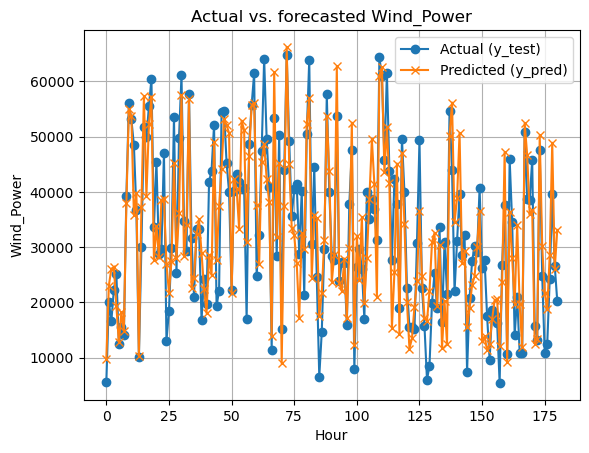

In [25]:
# training Parameters
train_start = 0 #in days, starting at midnight in Quebec
train_days =  1095
#train_hours = train_days * 24
test_days = 181
train_end = train_start + train_days

#test_hours = test_days * 24

#model hyperparameters
estimators = 150
depth = 20
randomstate= 614

#some things to initialize
#mape_scores = []
#r2_scores = []
y_pred = np.array([])

X_train = X.iloc[train_start:train_end]
y_train = y.iloc[train_start:train_end]

X_test = X.iloc[train_end:train_end+test_days]
y_test = y.iloc[train_end:train_end+test_days]

model = RandomForestRegressor(n_estimators=estimators, max_depth=depth, random_state=randomstate)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")



#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Hour')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()

MAPE: 0.2048
MAE: 5284.8198
R² Score: 0.8080


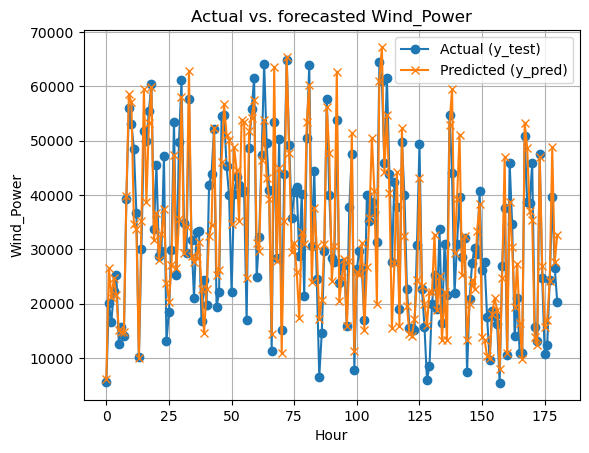

In [28]:


#some things to initialize
#mape_scores = []
#r2_scores = []
y_pred = np.array([])

X_train = X.iloc[train_start:train_end]
y_train = y.iloc[train_start:train_end]

X_test = X.iloc[train_end:train_end+test_days]
y_test = y.iloc[train_end:train_end+test_days]




# Set XGBoost parameters for regression using decision trees
params = {
    "objective": "reg:absoluteerror",   # regression with squared loss
    "max_depth": 6,                    # depth of each tree
    "eta": 0.01,                        # learning rate
    "nthread": 4,                      # number of threads
    "eval_metric": "rmse"             # evaluation metric
}

# Train the model
num_rounds = 10000

dtrain = xgb.DMatrix(X_train, label=y_train) #convert data type for XGB
dtest = xgb.DMatrix(X_test, label=y_test)



model = xgb.train(params, dtrain, num_rounds)

y_pred = model.predict(dtest)

mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Hour')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()